## 1. Imports

# Fine-tuning with LoRA

In [1]:
import json
import logging
import os
from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import mlx.nn as nn
import mlx.optimizers as optim
import pandas as pd
import torch
from mlx.utils import tree_flatten
from mlx_lm.generate import generate
from mlx_lm.tuner import datasets
from mlx_lm.tuner.callbacks import TrainingCallback
from mlx_lm.tuner.trainer import TrainingArgs, train
from mlx_lm.tuner.utils import linear_to_lora_layers
from mlx_lm.utils import load
from transformers import PreTrainedTokenizer

## 2. Metrics Callback

In [2]:
class Metrics(TrainingCallback):
    """A simple class to collect training and validation metrics."""
    
    def __init__(self) -> None:
        self.train_losses: list[tuple[int, float]] = []
        self.val_losses: list[tuple[int, float]] = []

    def on_train_loss_report(self, info: dict[str, Any]) -> None:
        self.train_losses.append((info["iteration"], info["train_loss"]))

    def on_val_loss_report(self, info: dict[str, Any]) -> None:
        self.val_losses.append((info["iteration"], info["val_loss"]))

## 3. Utility Functions

In [3]:
def find_project_root(marker=".git"):
    """Find the root directory of the project based on a marker file or directory."""
    path = Path(os.getcwd()).resolve()
    for parent in [path] + list(path.parents):
        if (parent / marker).exists():
            return parent
    return path


def df_to_str_dicts(df: pd.DataFrame) -> list[dict[str, str]]:
    """Convert DataFrame to list of string dictionaries.

    Args:
        df: DataFrame to convert

    Returns:
        List of dictionaries with string keys and values
    """
    records = df.to_dict(orient="records")
    result: list[dict[str, str]] = []

    for record in records:
        str_record = {
            str(k): str(v) if not pd.isna(v) else "" for k, v in record.items()
        }
        result.append(str_record)

    return result


def load_essay(
    file_path: Path | str,
    encoding: str = "utf-8",
) -> pd.DataFrame:
    """Load dataset from a single JSONL file.

    Args:
        file_path: Path to the JSONL file to load
        encoding: File encoding (default: utf-8)

    Returns:
        DataFrame containing the loaded data
    """
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    if not file_path.suffix == ".jsonl":
        raise ValueError(f"File must be a .jsonl file, got: {file_path.suffix}")

    try:
        df = pd.read_json(file_path, lines=True)
        df["dataset_source"] = file_path.name
        return df
    except ValueError:
        rows: list[dict] = []
        with file_path.open("r", encoding=encoding) as f:
            for i, line in enumerate(f, start=1):
                stripped = line.strip()
                if not stripped:
                    continue
                try:
                    row = json.loads(stripped)
                    row["dataset_source"] = file_path.name
                    rows.append(row)
                except json.JSONDecodeError:
                    logging.warning(
                        f"Skipping invalid JSON line {i} in {file_path}: {stripped}"
                    )

        if not rows:
            return pd.DataFrame()

        return pd.DataFrame(rows)


def truncate_text(tokenizer: PreTrainedTokenizer, text, max_len=512):
    """Truncate text at token level using the provided tokenizer.
    Uses encode/decode methods to ensure proper token-level truncation.

    Args:
        text: The text to truncate
        max_len: Maximum number of tokens
        tokenizer: A PreTrainedTokenizer instance (required)

    Returns:
        Truncated text string
    """
    if not isinstance(text, str):
        return ""

    if tokenizer is None:
        raise ValueError("tokenizer is required and cannot be None")

    # Encode text to token ids
    ids = tokenizer.encode(text)

    # Handle dict return type (some tokenizers return {"input_ids": [...]})
    if isinstance(ids, dict):
        ids = ids.get("input_ids", [])

    # Ensure ids is a list
    if isinstance(ids, tuple):
        ids = list(ids)
    elif not isinstance(ids, list):
        ids = list(ids) if hasattr(ids, "__iter__") else []

    # Check if already within limit
    if len(ids) <= max_len:
        return text

    # Truncate and decode - ids is now guaranteed to be list[int]
    truncated_ids: list[int] = ids[:max_len]  # type: ignore
    return tokenizer.decode(truncated_ids, skip_special_tokens=True)


def create_mlx_dataset(
    data: list[dict[str, str]],
    tokenizer: PreTrainedTokenizer,
    mask_prompt=True,
    prompt_key="instruction",
    completion_key="output",
) -> datasets.CacheDataset:
    """Create MLX-LM CacheDataset from dict list."""
    return datasets.CacheDataset(
        datasets.CompletionsDataset(
            data,
            tokenizer,
            prompt_key=prompt_key,
            completion_key=completion_key,
            mask_prompt=mask_prompt,
        )
    )

## 4. Training Functions

In [4]:
def train_lora_adapter(
    model: nn.Module,
    train_set: datasets.CacheDataset,
    valid_set: datasets.CacheDataset,
    adapter_dir: str | Path,
    lora_config: dict,
    iters: int = 200,
    steps_per_eval: int = 50,
    learning_rate: float = 1e-5,
    max_len: int = 2048,
) -> tuple[Any, Metrics]:
    """Fine-tune MLX-LM model with LoRA adapters."""
    adapter_dir = Path(adapter_dir)
    adapter_dir.mkdir(parents=True, exist_ok=True)
    adapter_config_path = adapter_dir / "adapter_config.json"
    adapter_file_path = adapter_dir / "adapters.safetensors"

    with open(adapter_config_path, "w") as f:
        json.dump(lora_config, f, indent=4)

    training_args = TrainingArgs(
        adapter_file=str(adapter_file_path),
        iters=iters,
        steps_per_eval=steps_per_eval,
        batch_size=30,
        val_batches=30,
        grad_checkpoint=True,
        max_seq_length=max_len,
    )
    model.freeze()
    linear_to_lora_layers(
        model, lora_config["num_layers"], lora_config["lora_parameters"]
    )

    num_train_params = sum(
        getattr(v, "size", 0) for _, v in tree_flatten(model.trainable_parameters())
    )
    print(f"Number of trainable parameters: {num_train_params}")

    model.train()
    opt = optim.Adam(learning_rate=learning_rate)

    metrics = Metrics()
    train(
        model=model,
        args=training_args,
        optimizer=opt,
        train_dataset=train_set,
        val_dataset=valid_set,
        training_callback=metrics,
    )
    return model, metrics

## 5. Configuration

In [5]:
# --- Model and Training Configuration ---
MODEL_NAME = "mlx-community/gemma-3-270m-it-4bit"
OUTPUT_DIR = "gemma-3-270m-it-4bit"
MAX_LEN = 2048 * 3

# --- Project Paths ---
PROJECT_ROOT = find_project_root()
BASE_DATA_DIR = PROJECT_ROOT / "data"
BASE_ADAPTER_DIR = PROJECT_ROOT / "adapters"

RAW_DIR = BASE_DATA_DIR / "raw"
PROCESSED_DIR = BASE_DATA_DIR / "processed"
ADAPTER_PATH = BASE_ADAPTER_DIR / OUTPUT_DIR

# --- LoRA Configuration ---
LORA_CONFIG = {
    "num_layers": 32,
    "lora_parameters": {"rank": 64, "scale": 64, "dropout": 0.05},
}

## 6. Load Model and Tokenizer

In [6]:
model, tokenizer, *_ = load(MODEL_NAME)

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

## 7. Load and Process Dataset

In [7]:
train_set = df_to_str_dicts(load_essay(PROCESSED_DIR / "train.jsonl"))
test_set = df_to_str_dicts(load_essay(PROCESSED_DIR / "test.jsonl"))
valid_set = df_to_str_dicts(load_essay(PROCESSED_DIR / "val.jsonl"))

In [8]:
tokenizer = cast(PreTrainedTokenizer, tokenizer)

train_mlx_set, test_mlx_set, valid_mlx_set = [
    create_mlx_dataset(
        data,
        tokenizer,
        mask_prompt=True,
        prompt_key="instruction",
        completion_key="output",
    )
    for data in (train_set, test_set, valid_set)
]

## 8. Train LoRA Adapter

In [9]:
print(f"LoRA adapter will be saved to {ADAPTER_PATH}")
model, metrics = train_lora_adapter(
    model, train_mlx_set, valid_mlx_set, ADAPTER_PATH, LORA_CONFIG, max_len=MAX_LEN,
)

# Clean up memory
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
elif (
    getattr(torch.backends, "mps", None) is not None
    and torch.backends.mps.is_available()
):
    try:
        torch.mps.empty_cache()
    except AttributeError:
        pass

LoRA adapter will be saved to /Users/hyan/Workspaces/aibox-nes-slms/adapters/gemma-3-270m-it-4bit
Number of trainable parameters: 15187968
Starting training..., iters: 200


Calculating loss...: 100%|██████████| 4/4 [00:04<00:00,  1.08s/it]

Iter 1: Val loss 2.291, Val took 4.323s


Iter 10: Train loss 1.469, Learning Rate 1.000e-05, It/sec 0.312, Tokens/sec 411.736, Trained Tokens 13200, Peak mem 13.549 GB
Iter 20: Train loss 0.218, Learning Rate 1.000e-05, It/sec 0.316, Tokens/sec 416.654, Trained Tokens 26400, Peak mem 13.549 GB
Iter 30: Train loss 0.116, Learning Rate 1.000e-05, It/sec 0.317, Tokens/sec 418.096, Trained Tokens 39600, Peak mem 13.549 GB
Iter 40: Train loss 0.098, Learning Rate 1.000e-05, It/sec 0.316, Tokens/sec 417.398, Trained Tokens 52800, Peak mem 13.549 GB


Calculating loss...: 100%|██████████| 4/4 [00:04<00:00,  1.07s/it]

...

Iter 150: Val loss 0.087, Val took 4.266s


Iter 150: Train loss 0.085, Learning Rate 1.000e-05, It/sec 0.315, Tokens/sec 416.136, Trained Tokens 198000, Peak mem 13.610 GB
Iter 160: Train loss 0.087, Learning Rate 1.000e-05, It/sec 0.317, Tokens/sec 418.946, Trained Tokens 211200, Peak mem 13.610 GB
Iter 170: Train loss 0.078, Learning Rate 1.000e-05, It/sec 0.314, Tokens/sec 414.221, Trained Tokens 224400, Peak mem 13.610 GB
Iter 180: Train loss 0.082, Learning Rate 1.000e-05, It/sec 0.315, Tokens/sec 416.058, Trained Tokens 237600, Peak mem 13.610 GB
Iter 190: Train loss 0.088, Learning Rate 1.000e-05, It/sec 0.318, Tokens/sec 419.612, Trained Tokens 250800, Peak mem 13.610 GB


Calculating loss...: 100%|██████████| 4/4 [00:04<00:00,  1.06s/it]

Iter 200: Val loss 0.085, Val took 4.272s


Iter 200: Train loss 0.084, Learning Rate 1.000e-05, It/sec 0.317, Tokens/sec 418.601, Trained Tokens 264000, Peak mem 13.610 GB
Iter 200: Saved adapter weights to /Users/hyan/Workspaces/aibox-nes-slms/adapters/gemma-3-270m-it-4bit/adapters.safetensors and /Users/hyan/Workspaces/aibox-nes-slms/adapters/gemma-3-270m-it-4bit/0000200_adapters.safetensors.
Saved final weights to /Users/hyan/Workspaces/aibox-nes-slms/adapters/gemma-3-270m-it-4bit/adapters.safetensors.


## 9. Plot Training Metrics

Training plot saved to /Users/hyan/Workspaces/aibox-nes-slms/data/processed/training_loss_plot.png


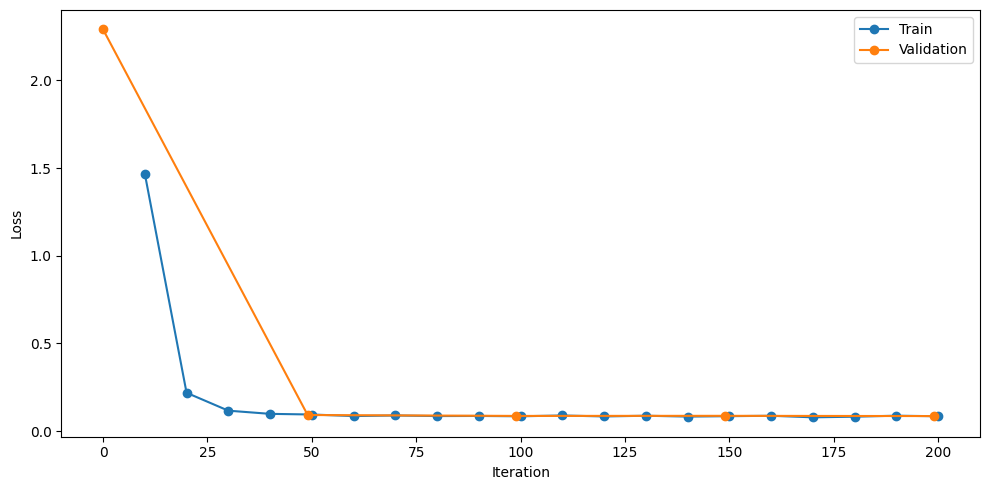

In [10]:
train_its, train_losses = zip(*metrics.train_losses)
val_its, val_losses = zip(*metrics.val_losses)

plt.figure(figsize=(10, 5))
plt.plot(train_its, train_losses, "-o", label="Train")
plt.plot(val_its, val_losses, "-o", label="Validation")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

plot_path = PROCESSED_DIR / "training_loss_plot.png"
plt.savefig(plot_path)
print(f"Training plot saved to {plot_path}")
plt.show()

## 10. Test Fine-Tuned Model

In [12]:
model_lora, *_ = load(MODEL_NAME, adapter_path=str(ADAPTER_PATH))

test_sample = train_set[1]
prompt = test_sample["instruction"]

messages = [{"role": "user", "content": prompt}]
prompt_text = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)

if not isinstance(prompt_text, str):
    raise TypeError(f"Expected string prompt, got {type(prompt_text)}")

print(f"Testing model with prompt: '{prompt}'")
print(f"Expected output: {test_sample['output']}\n")
response = generate(model_lora, tokenizer, prompt=prompt_text, verbose=True)

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Testing model with prompt: 'Você é um especialista no ensino de redação narrativa para alunos do ensino fundamental. Dada uma determinada entrada (uma redação narrativa), seu papel é avaliá-la nas seguintes competências: registro formal, coerência temática, estrutura retórica narrativa e coesão. Sua nota deve ir de 1 à 5, sendo 1 a menor nota e 5 a maior. A saída deve ser um dicionário com as notas de cada competência, por exemplo: {"formal_register": 5, "themetic_coherence": 2, "narrative_rhetorical_structure": 4, "cohesion": 3}'
Expected output: {"formal_register": 2, "thematic_coherence": 2, "narrative_rhetorical_structure": 3, "cohesion": 2}

{"formal_register": 3, "thematic_coherence": 3, "narrative_rhetorical_structure": 4, "cohesion": 3}
Prompt: 143 tokens, 2659.739 tokens-per-sec
Generation: 39 tokens, 171.604 tokens-per-sec
Peak memory: 13.610 GB
